In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# Necessary Functions

### 1. Mean Squared Error (MSE)

$$
\text{MSE} = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

### 2. Root Mean Squared Error (RMSE)

$$
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

### 3. Mean Absolute Error (MAE)

$$
\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

### 4. Coefficient of Determination \(R^2\)

First define the mean target:

$$
\bar{y} = \frac{1}{n}\sum_{i=1}^{n} y_i
$$

Then:

$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
           {\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$

### 5. Root Mean Squared Under-Prediction Error (RMSUE)

Define under-prediction for each point as:

$$
u_i = \max(y_i - \hat{y}_i,\, 0)
$$

Then:

$$
\text{RMSUE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} u_i^2}
= \sqrt{\frac{1}{n}\sum_{i=1}^{n} \big(\max(y_i - \hat{y}_i, 0)\big)^2}
$$

### 6. Under-Prediction Rate (UP-Rate)

Using the indicator function :

$$
\text{UP-Rate} = \frac{1}{n}\sum_{i=1}^{n} \mathbf{1}(y_i > \hat{y}_i)
$$


### Metrics and Purpose
- **RMSE & MAE** tell us how accurate the model is overall.
- **R²** tells us how much useful variance the model captures.
- **RMSUE & UnderPredictionRate** tell us how risky the model is in real estate pricing.

### Plot Interpretations

**Bar Chart – Metric Comparison**  
Shows accuracy vs. risk metrics across models. Lower RMSE/MAE/RMSUE is better; lower UnderPredictionRate means less financial risk.

**Residual Histogram**  
Shows distribution of prediction errors. Centered near 0 means unbiased predictions; wider spread means more instability.

**Under-Prediction Histogram**  
Shows only risky under-estimation errors. Short tails = safer, fewer big misses. Long tails = dangerous for lenders.

**True vs Predicted Scatter Plot**  
Compares model predictions to actual values. Points close to the diagonal = accurate. Points below line = under-predict (risk).




In [34]:

def regression_metrics(y_true, y_pred):
    """
    Compute standard regression metrics + risk-averse metrics.

    Returns a dict with:
      - RMSE
      - MAE
      - R2
      - RMSUE  (Root Mean Squared Under-prediction Error)
      - UnderPredictionRate (fraction of points where y_true > y_pred)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    diff  = y_true - y_pred
    under = np.where(diff > 0, diff, 0.0)    
    rmsue = np.sqrt(np.mean(under**2)) if np.any(under > 0) else 0.0
    under_rate = np.mean(diff > 0)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "RMSUE": rmsue,
        "UnderPredictionRate": under_rate
    }

def evaluate_models(y_true, preds_dict):
    """
    preds_dict: {"model_name": y_pred_array, ...}

    Returns a DataFrame with metrics for each model.
    """
    rows = {}
    for name, y_pred in preds_dict.items():
        rows[name] = regression_metrics(y_true, y_pred)
    metrics_df = pd.DataFrame(rows).T
    return metrics_df


def plot_metric_bars(metrics_df, metrics=None, figsize=(8, 4), title=None):
    """
    Bar chart comparing selected metrics across models.
    metrics_df: output of evaluate_models
    metrics: list like ["RMSE", "MAE", "RMSUE", "UnderPredictionRate"]
    """
    if metrics is None:
        metrics = ["RMSE", "MAE", "RMSUE", "UnderPredictionRate"]

    ax = metrics_df[metrics].plot(kind="bar", figsize=figsize, rot=0)
    ax.set_ylabel("Score")
    if title:
        ax.set_title(title)
    plt.tight_layout()
    plt.show()

def plot_residual_histograms(y_true, preds_dict, bins=30, figsize=(8, 4), title=None):
    """
    Overlay histograms of residuals (y_true - y_pred) for multiple models.
    """
    y_true = np.asarray(y_true)

    plt.figure(figsize=figsize)
    for name, y_pred in preds_dict.items():
        y_pred = np.asarray(y_pred)
        residuals = y_true - y_pred
        plt.hist(residuals, bins=bins, alpha=0.5, label=name, density=True)

    plt.axvline(0, color="k", linestyle="--", linewidth=1)
    plt.xlabel("Residual (y_true - y_pred)")
    plt.ylabel("Density")
    if title:
        plt.title(title)
    else:
        plt.title("Residual Distributions")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_true_vs_pred(y_true, preds_dict, figsize=(5, 5), title=None):
    """
    Scatter plot of true vs predicted for multiple models.
    """
    y_true = np.asarray(y_true)
    min_y, max_y = y_true.min(), y_true.max()

    plt.figure(figsize=figsize)
    for name, y_pred in preds_dict.items():
        y_pred = np.asarray(y_pred)
        plt.scatter(y_true, y_pred, alpha=0.6, label=name)

    plt.plot([min_y, max_y], [min_y, max_y], "k--", label="Ideal y = ŷ")
    plt.xlabel("True target")
    plt.ylabel("Predicted target")
    if title:
        plt.title(title)
    else:
        plt.title("True vs Predicted")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_underprediction_histograms(y_true, preds_dict, bins=30, figsize=(8, 4), title=None):
    """
    Show distribution of under-prediction errors (y_true - y_pred > 0) for each model.
    Good for risk-averse analysis.
    """
    y_true = np.asarray(y_true)

    plt.figure(figsize=figsize)
    for name, y_pred in preds_dict.items():
        y_pred = np.asarray(y_pred)
        diff = y_true - y_pred
        under_errors = diff[diff > 0] 
        if under_errors.size == 0:
            continue
        plt.hist(under_errors, bins=bins, alpha=0.5, label=name, density=True)

    plt.xlabel("Under-prediction amount (y_true - y_pred, only > 0)")
    plt.ylabel("Density")
    if title:
        plt.title(title)
    else:
        plt.title("Under-prediction Error Distributions")
    plt.legend()
    plt.tight_layout()
    plt.show()


Dataset Description
The dataset contains a total of 506 cases. Features below:

CRIM - per capita crime rate by town

ZN - proportion of residential land zoned for lots over 25,000 sq.ft.

INDUS - proportion of non-retail business acres per town.

CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)

NOX - nitric oxides concentration (parts per 10 million)

RM - average number of rooms per dwelling

AGE - proportion of owner-occupied units built prior to 1940

DIS - weighted distances to five Boston employment centres

RAD - index of accessibility to radial highways

TAX - full-value property-tax rate per $10,000

PTRATIO - pupil-teacher ratio by town

B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town

LSTAT - % lower status of the population

MEDV - Median value of owner-occupied homes in $1000's

In [35]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df_bostonhousing = pd.read_csv("./housing.csv", header=None, delimiter=r"\s+", names=column_names)
df_bostonhousing.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


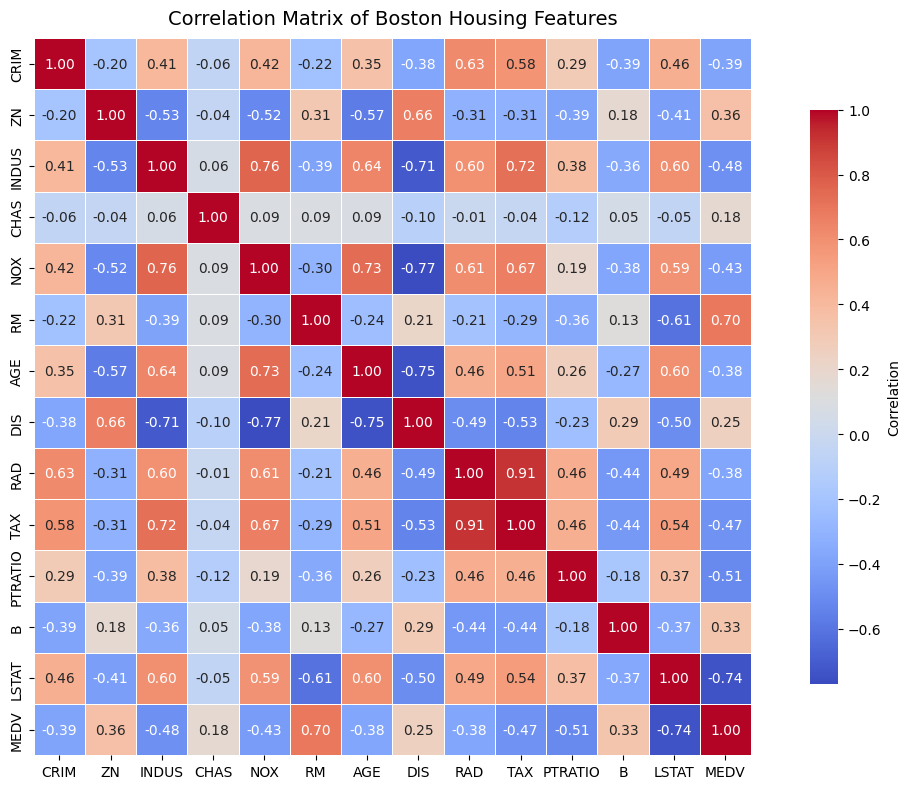

In [36]:


corr = df_bostonhousing.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,          
    fmt=".2f",          
    cmap="coolwarm",     
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation"}
)

plt.title("Correlation Matrix of Boston Housing Features", fontsize=14, pad=10)
plt.tight_layout()
plt.show()


We will be dropping the column B to ensure fairness. Also dropping CHAS as it's a dummy column and has little to no value.

CHAS has little affect on everything, Hence we can consider dropping it

In [37]:
df_bostonhousing.drop("B", axis=1, inplace=True)

df_bostonhousing.drop("CHAS", axis=1, inplace=True)

df_bostonhousing.head()


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222.0,18.7,5.33,36.2


# Correlation Matrix Main before any preprocessing

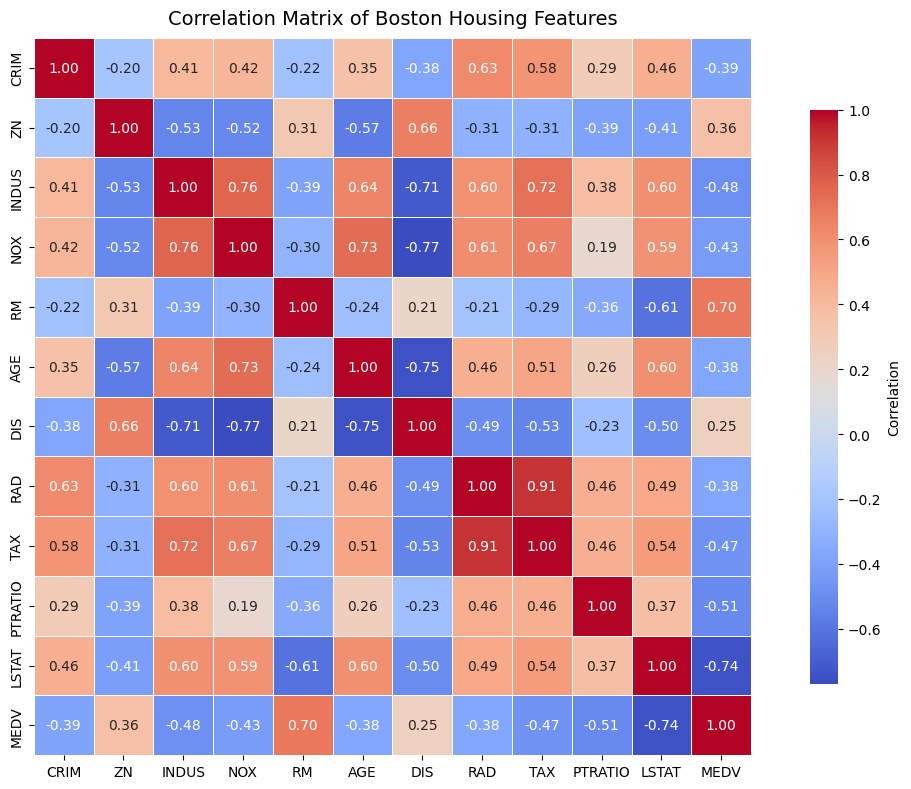

In [38]:

corr = df_bostonhousing.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,          
    fmt=".2f",           
    cmap="coolwarm",     
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation"}
)

plt.title("Correlation Matrix of Boston Housing Features", fontsize=14, pad=10)
plt.tight_layout()
plt.show()

# Inference from the correlation matrix 

RM (+0.70)
More average rooms per dwelling = higher median house value 
 
Bigger houses are worth more

LSTAT (−0.74)
Percentage of lower-status population = lower house value

Neighborhood socioeconomic status strongly affects price

PTRATIO (−0.51)
Higher pupilteacher ratio = lower house value

Worse schools cheaper houses

NOX (−0.43), INDUS (−0.48), TAX (−0.47), CRIM (−0.39), RAD (−0.38), AGE (−0.38)

All are moderately negatively correlated with MEDV.


In [39]:
df_bostonhousing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   NOX      506 non-null    float64
 4   RM       506 non-null    float64
 5   AGE      506 non-null    float64
 6   DIS      506 non-null    float64
 7   RAD      506 non-null    int64  
 8   TAX      506 non-null    float64
 9   PTRATIO  506 non-null    float64
 10  LSTAT    506 non-null    float64
 11  MEDV     506 non-null    float64
dtypes: float64(11), int64(1)
memory usage: 47.6 KB


In [40]:
df_bostonhousing.shape

(506, 12)

It’s a small tabular dataset

risk of overfitting

need careful validation

All columns are numeric
no encoding needed
every feature is ready for most ML models

RAD is stored as int64 but is really an ordinal category (124).

For Random Forest, treat it as numeric.

For linear models, consider one-hot later

In [41]:
df_bostonhousing.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


CRIM  per capita crime rate <br> 
    =strong right-skew <br>
    =consider log-transform for linear models <br>
    =for Random Forest it’s less critical<br>

ZN  proportion of residential land zoned for large lots<br>
    =zero-inflated & right-skewed  <br>
    =treat “ZN>0” as a binary indicator later if useful<br>

INDUS  proportion of non-retail business acres <br>
    =moderate right-skew <br>

NOX  nitric oxides concentration <br>
    =narrow range, mild right-skew<br>

RM  average rooms per dwelling <br>
    =symmetric<br>

AGE  proportion of units built before 1940 <br>
    =left-skewed<br>

DIS  distance to employment centers <br>
    =right-skewed<br>

RAD  index of radial highways<br>
    = looks categorical-ish hence for linear models, one-hot might help. For trees, numeric is fine <br>

TAX  property-tax rate<br>
    =right-skewed<br>
    = correlated with RAD/INDUS<br>

PTRATIO  pupilteacher ratio<br>
    =Slight left-skew<br>

LSTAT  % lower status population<br>
    =strong right-skew<br>
    =very strong predictor for MEDV, with many outliers at the high end<br>

MEDV  target (median home value, $1000’s)<br>
    = Slight right-skew<br>

In [42]:
df_bostonhousing.isnull().sum()

CRIM       0
ZN         0
INDUS      0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
LSTAT      0
MEDV       0
dtype: int64

In [43]:
df_bostonhousing.duplicated().sum()

np.int64(0)

All features show 0 missing values and no duplicates

# Histogram plots for the columns

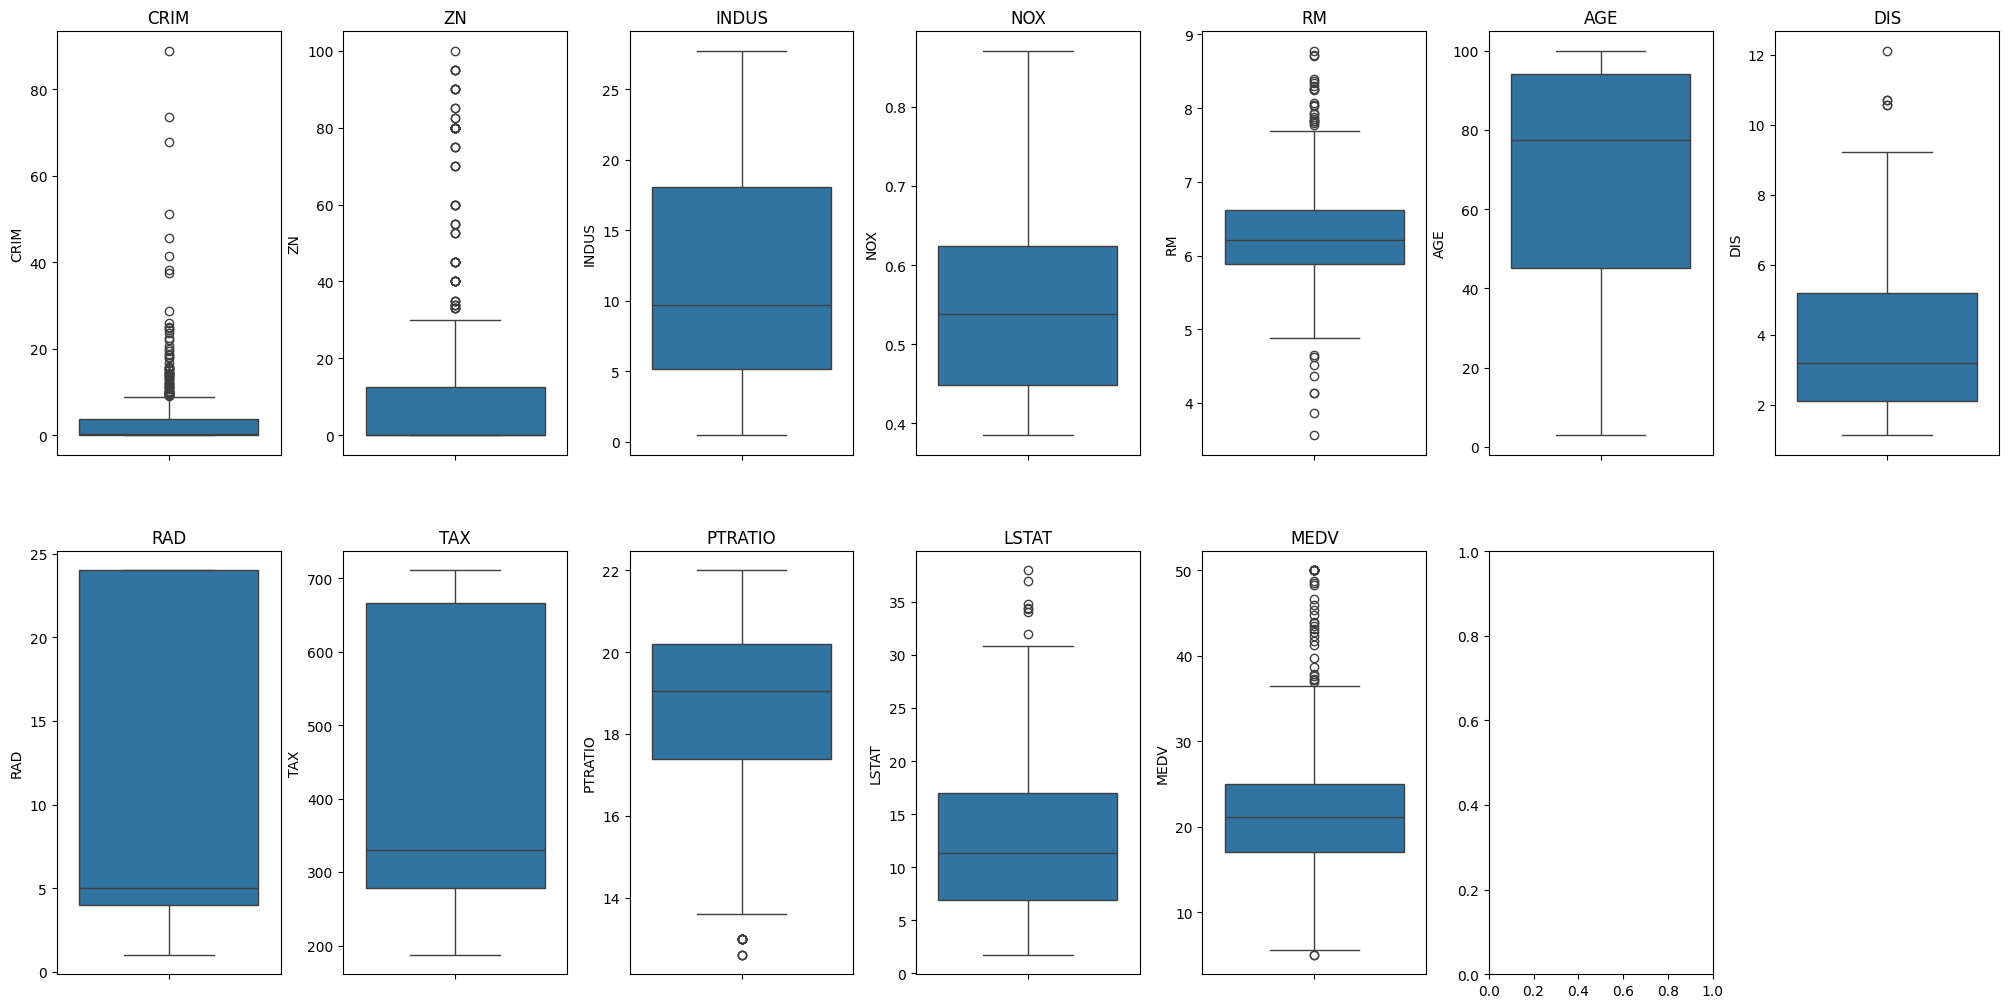

In [44]:
fig, ax = plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
ax = ax.flatten()

for i, col in enumerate(df_bostonhousing.columns):
    sns.boxplot(y=df_bostonhousing[col], ax=ax[i])
    ax[i].set_title(col)

fig.delaxes(ax[13])
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)
plt.show()


CRIM:
Tight box near 0 and many high outliers
Strong candidate for log-transform in linear models
 Random Forest handles it but outliers reflect meaningful variation

ZN:
Box near 0 with lots of zeros which confirms zero-inflation + outliers
Potential binary feature (ZN>0) or sparse continuous feature

INDUS:
Moderate spread, a few outliers on the high side
Relatively stable continuous predictor

NOX:
Moderate spread, some high outliers
negatively correlated with MEDV

RM:
 few low and high outliers 
 Strong predictor of MEDV

AGE:
Box biased toward high values (many old units), with some low-AGE outliers (newer developments).

DIS:
Box low, lots of points higher up  right-skew
Several high-distance outliers

RAD:
discrete boxplot with many points at the top (24).
Shows strong discretization and mass at one category.
Might be treated as categorical in linear models
numeric fine for RF

TAX:
Wide box, many high outliers near 600

PTRATIO:
Relatively compact distribution
not many extreme outliers
Stable continuous feature

LSTAT:
 lots of high outliers 
 inverse predictor of MEDV.

MEDV:
 a bunch of points up at 50 with capping at 50 and some low outliers near 5.

risk-averse loss
 ![alt text](image.png)

quantile regression would be better
![alt text](image-1.png)

trimming should help
Remove rows where MEDV = 50 when training the regression model
Then you’re only modeling the range 5 to <50 where labels are better
but you lose info about the high-end market.


In [45]:
nunique_series = df_bostonhousing.nunique().sort_values()
print(nunique_series)


var_series = df_bostonhousing.var().sort_values()
print("\nVariance per feature:\n", var_series)

RAD          9
ZN          26
PTRATIO     46
TAX         66
INDUS       76
NOX         81
MEDV       229
AGE        356
DIS        412
RM         446
LSTAT      455
CRIM       504
dtype: int64

Variance per feature:
 NOX            0.013428
RM             0.493671
DIS            4.434015
PTRATIO        4.686989
INDUS         47.064442
LSTAT         50.994760
CRIM          73.986578
RAD           75.816366
MEDV          84.586724
ZN           543.936814
AGE          792.358399
TAX        28404.759488
dtype: float64


Nunique:
For linear models, RAD (and maybe ZN) are good candidates for one-hot
For Random Forest, all of them can stay numeric

Variance per feature:
For standardized linear models, scale everything so these variance differences don’t dominate.
For Random Forest, no scaling needed as the tree splits ignore global scale

MEDV max: 50.0
Number of rows with MEDV = 50: 16
Total rows: 506
Proportion at 50: 0.03162055335968379


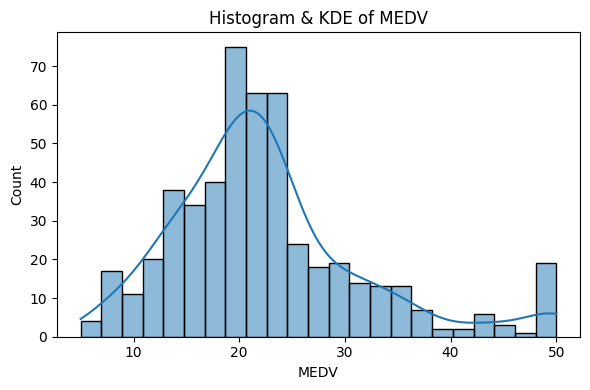

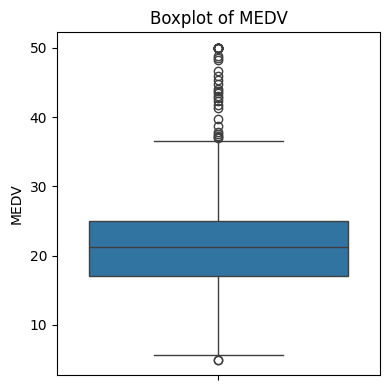

Skewness of MEDV: 1.1080984082549072


In [46]:
medv = df_bostonhousing["MEDV"]

print("MEDV max:", medv.max())
print("Number of rows with MEDV = 50:", (medv == 50).sum())
print("Total rows:", len(medv))
print("Proportion at 50:", (medv == 50).mean())

plt.figure(figsize=(6, 4))
sns.histplot(medv, kde=True)
plt.title("Histogram & KDE of MEDV")
plt.xlabel("MEDV")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 4))
sns.boxplot(y=medv)
plt.title("Boxplot of MEDV")
plt.ylabel("MEDV")
plt.tight_layout()
plt.show()

medv_skew = medv.skew()
print("Skewness of MEDV:", medv_skew)


MEDV is capped at 50 hence can cause issues with the model. We can try trimming and see of the performance is better. For now go ahead without trimming the data cuz that's safer and we have limited data points.

also this skew can make residuals non-normal - Transform the target adding log is something we can try

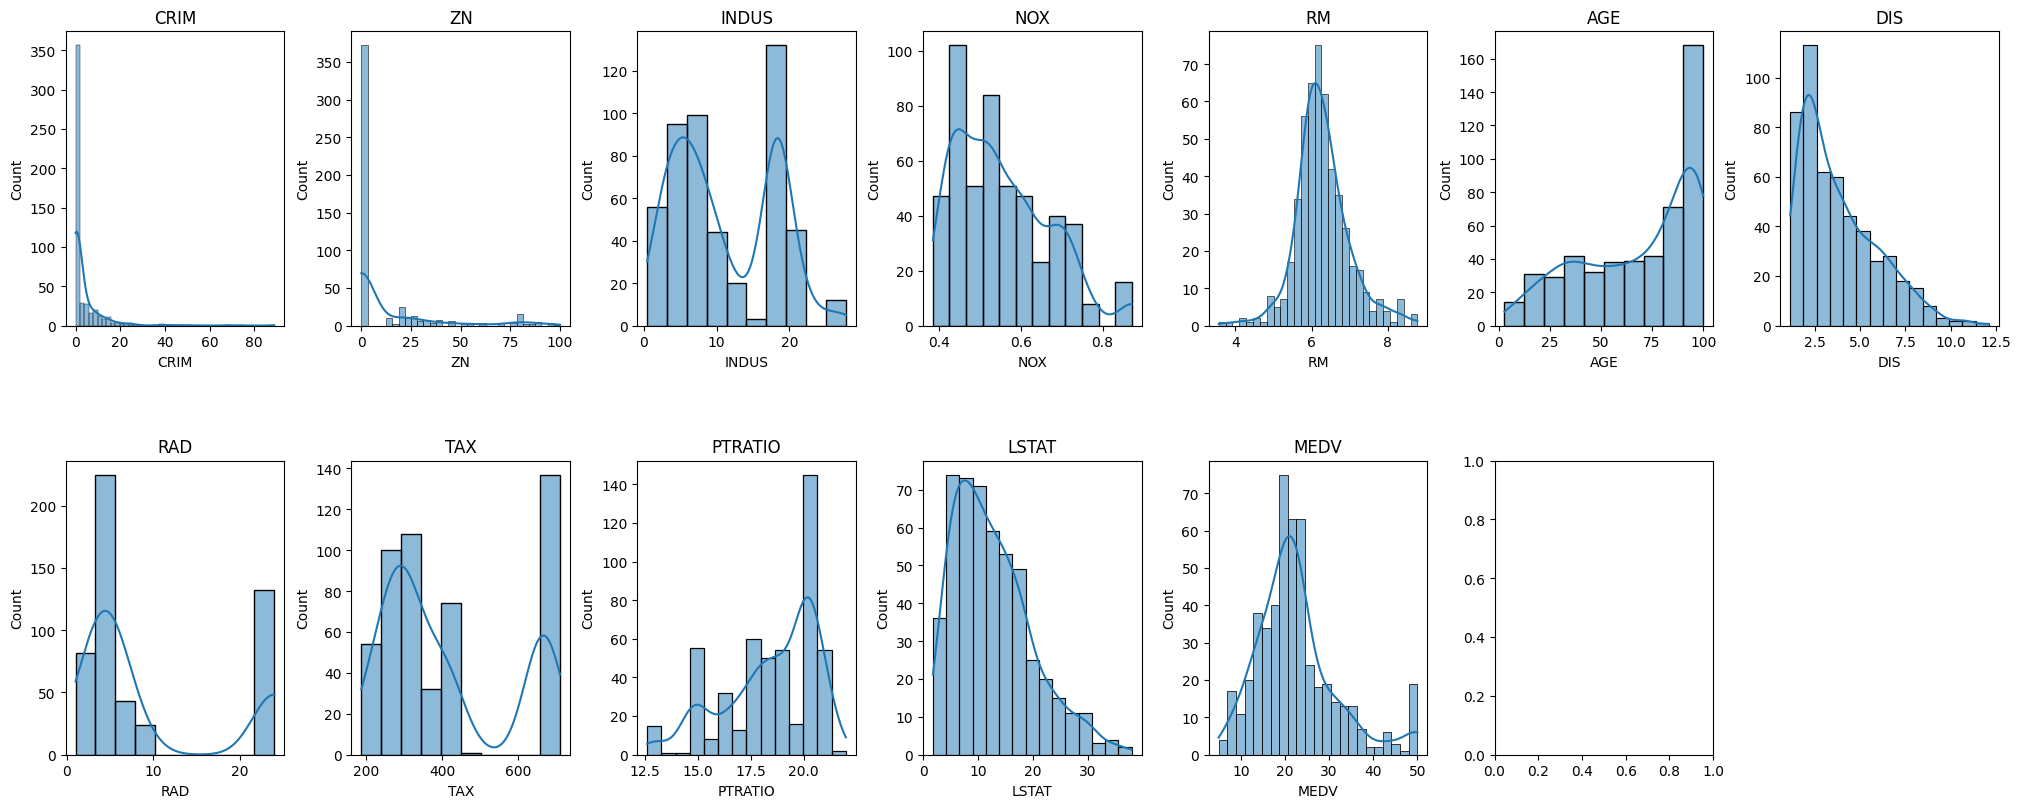

In [47]:
fig, ax = plt.subplots(ncols=7, nrows=2, figsize=(20, 8))
ax = ax.flatten()

for i, col in enumerate(df_bostonhousing.columns):
    sns.histplot(df_bostonhousing[col], ax=ax[i], kde=True)
    ax[i].set_title(col)
fig.delaxes(ax[13])
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)
plt.show()



# Linear models preprocessing

## Log transformations on crim dis tax and lstat

In [48]:

df_bostonhousing_linear = df_bostonhousing.copy()

target_col = "MEDV"

df_bostonhousing_linear["CRIM_log"]  = np.log1p(df_bostonhousing_linear["CRIM"])
df_bostonhousing_linear["DIS_log"]   = np.log1p(df_bostonhousing_linear["DIS"])
df_bostonhousing_linear["TAX_log"]   = np.log1p(df_bostonhousing_linear["TAX"])
df_bostonhousing_linear["LSTAT_log"] = np.log1p(df_bostonhousing_linear["LSTAT"])

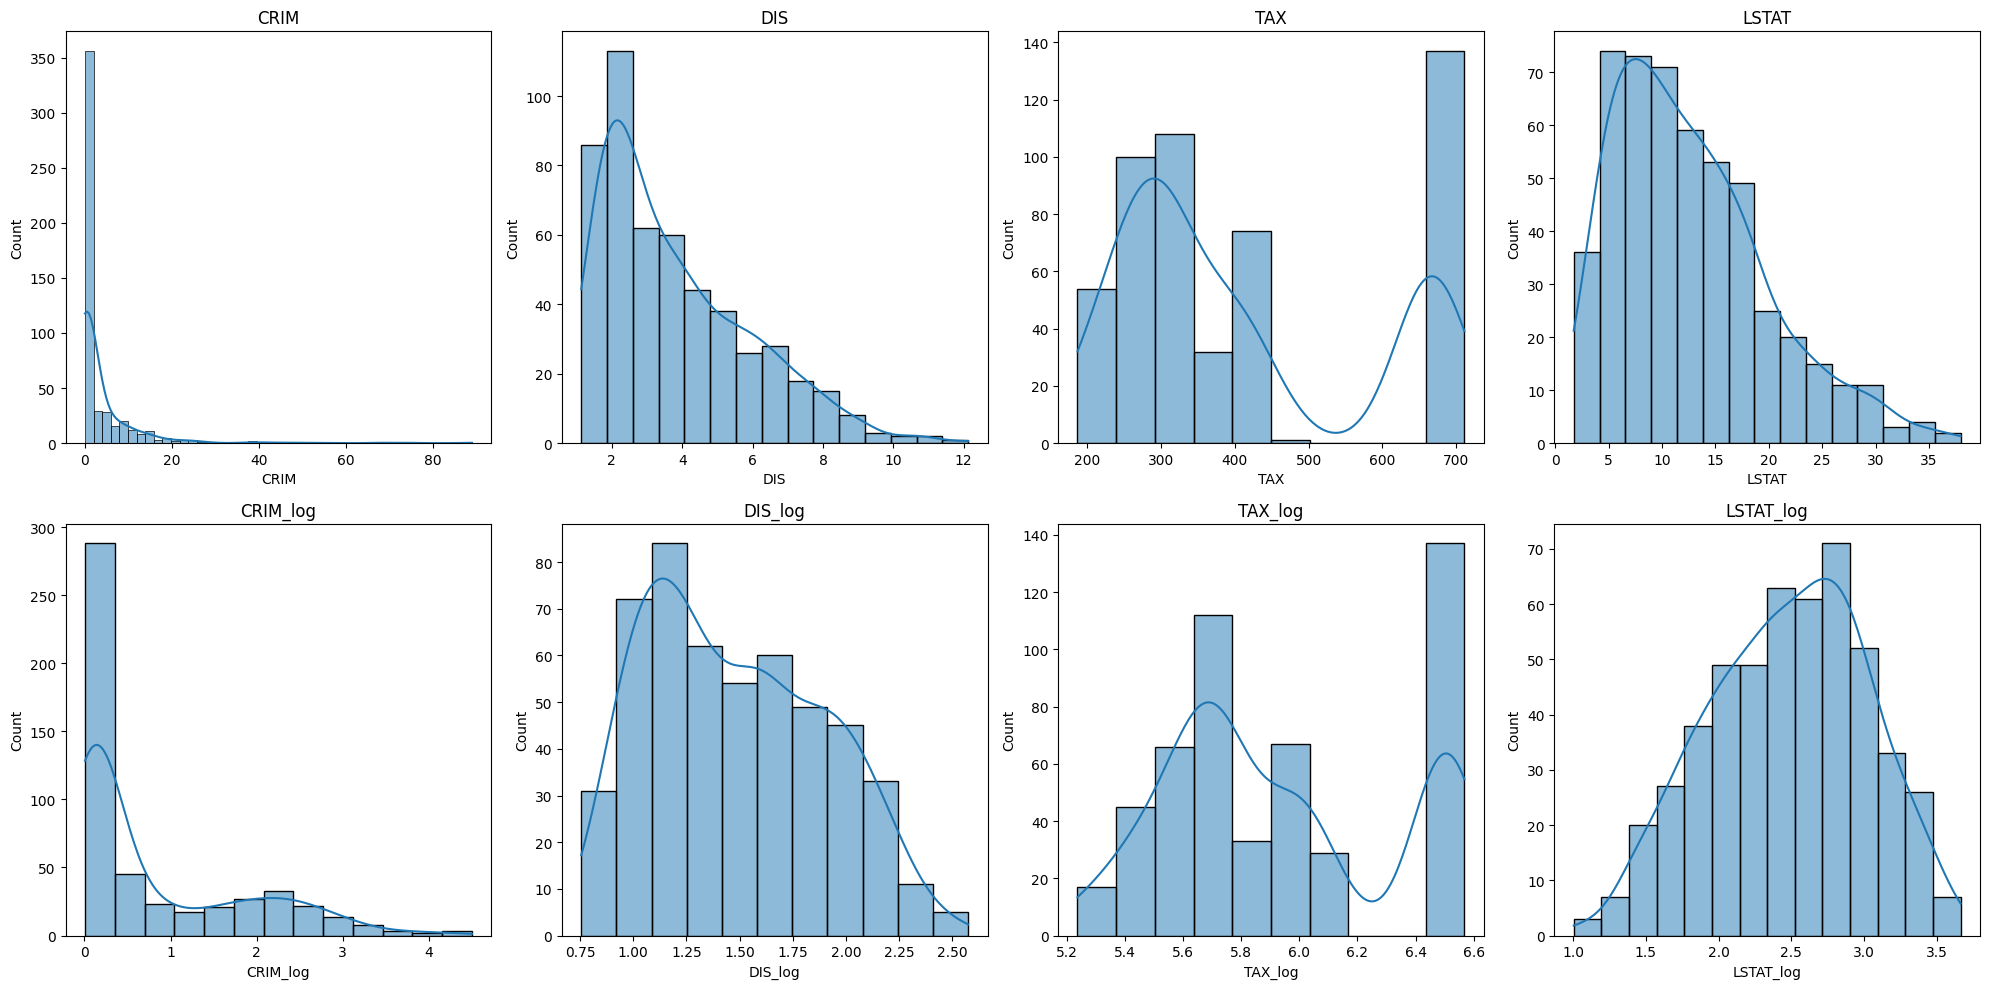

In [49]:
fig, ax = plt.subplots(ncols=4, nrows=2, figsize=(20, 10))
ax = ax.flatten()
cols = ['CRIM', 'DIS', 'TAX', 'LSTAT', 'CRIM_log', 'DIS_log', 'TAX_log', 'LSTAT_log']
for i, col in enumerate(cols):
    sns.histplot(df_bostonhousing_linear[col], ax=ax[i], kde=True)
    ax[i].set_title(f'{col}')
plt.tight_layout()
plt.show()

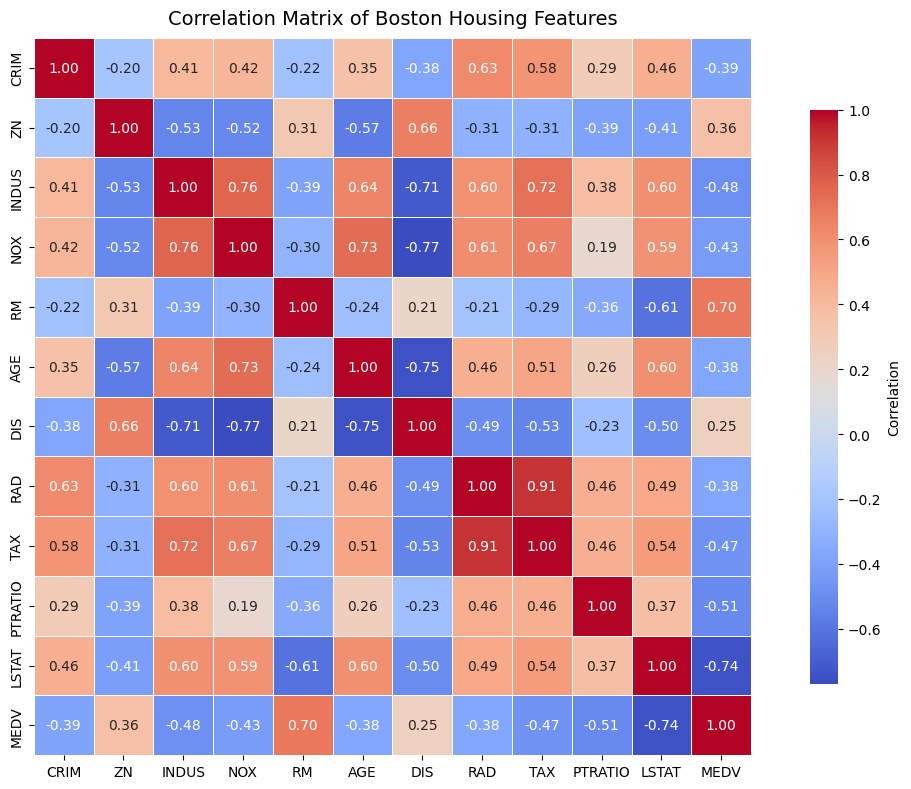

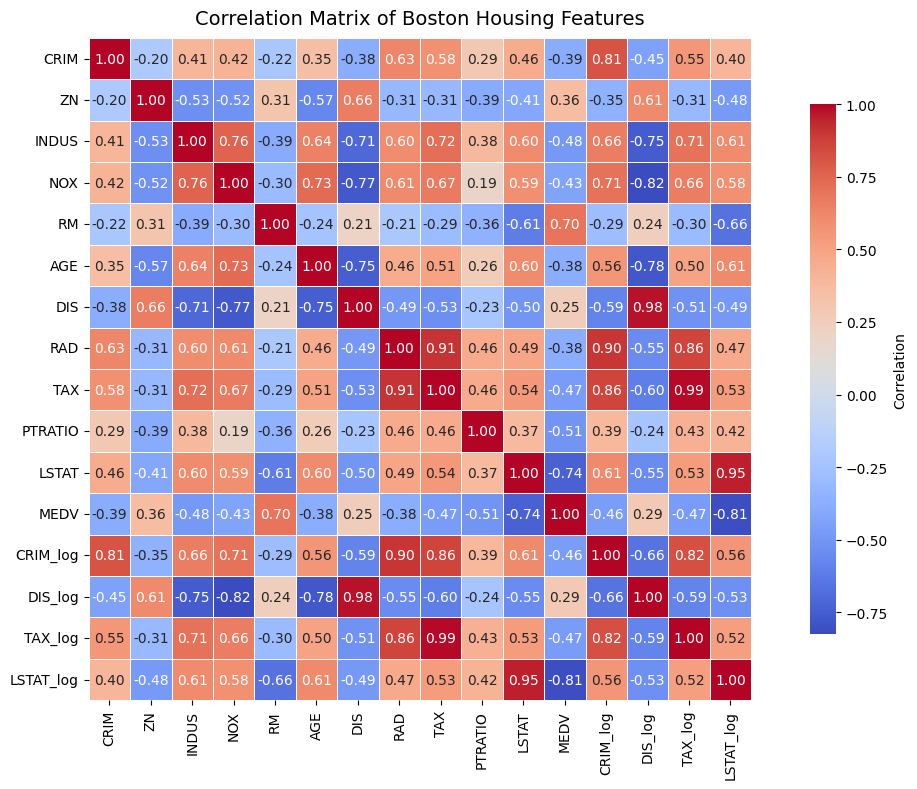

In [50]:

corr = df_bostonhousing.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,          
    fmt=".2f",           
    cmap="coolwarm",     
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation"}
)

plt.title("Correlation Matrix of Boston Housing Features", fontsize=14, pad=10)
plt.tight_layout()
plt.show()


corr = df_bostonhousing_linear.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,          
    fmt=".2f",           
    cmap="coolwarm",     
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation"}
)

plt.title("Correlation Matrix of Boston Housing Features", fontsize=14, pad=10)
plt.tight_layout()
plt.show()

In [51]:
df_bostonhousing_linear = df_bostonhousing_linear.drop(
    columns=["CRIM", "DIS", "TAX", "LSTAT"]
)

## One hot encoding

In [52]:

X_linear_raw = pd.get_dummies(
    df_bostonhousing_linear.drop(columns=[target_col]),
    columns=["RAD", "ZN"],
    drop_first=True
)

X_linear_raw.head()

save_path = "./X_linear_raw.csv"
X_linear_raw.to_csv(save_path, index=False)
print(f"Saved X_linear_raw to {save_path}")

Saved X_linear_raw to ./X_linear_raw.csv


### medv is capped and has large values hence we need to try with both 

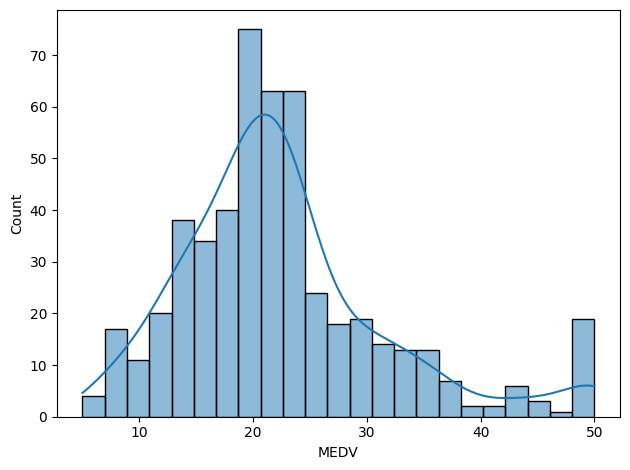

In [53]:


y_linear_normal = df_bostonhousing_linear[target_col]

sns.histplot(y_linear_normal, kde=True)
plt.tight_layout()
plt.show()



## TRAIN TEST SPLIT

In [54]:
n_bins = 5
y_strata = pd.qcut(y_linear_normal, q=n_bins, labels=False, duplicates="drop")

sss = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_idx, test_idx in sss.split(X_linear_raw, y_strata):
    X_train_raw = X_linear_raw.iloc[train_idx]
    X_test_raw  = X_linear_raw.iloc[test_idx]

    y_train_normal = y_linear_normal.iloc[train_idx]
    y_test_normal  = y_linear_normal.iloc[test_idx]
    
# Orignal data split 
for train_original_idx, test_original_idx in sss.split(df_bostonhousing, y_strata):
    X_train_original = df_bostonhousing.iloc[train_original_idx].drop(columns=[target_col])
    X_test_original  = df_bostonhousing.iloc[test_original_idx].drop(columns=[target_col])

    y_train_original = df_bostonhousing.iloc[train_original_idx][target_col]
    y_test_original  = df_bostonhousing.iloc[test_original_idx][target_col]

scaler_linear = StandardScaler()
X_train_scaled = scaler_linear.fit_transform(X_train_raw)
X_test_scaled  = scaler_linear.transform(X_test_raw)

feature_names_linear = X_linear_raw.columns


In [55]:


ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train_normal)

y_pred_ridge = ridge.predict(X_test_scaled)
rmse_ridge = root_mean_squared_error(y_test_normal, y_pred_ridge)
print("Ridge RMSE (normal target):", rmse_ridge)

metrics_scaled = regression_metrics(y_test_normal, y_pred_ridge)
print(metrics_scaled)

ridge2 = Ridge(alpha=1.0, random_state=42)
ridge2.fit(X_train_raw, y_train_normal)

y_pred_ridge2 = ridge2.predict(X_test_raw)
rmse_ridge2 = root_mean_squared_error(y_test_normal, y_pred_ridge2)
print("Ridge RMSE 2 non scaled(normal target):", rmse_ridge2)

metrics_nonscaled = regression_metrics(y_test_normal, y_pred_ridge2)
print(metrics_nonscaled)

ridgeOriginal = Ridge(alpha=1.0, random_state=42)
ridgeOriginal.fit(X_train_original, y_train_original)

y_pred_ridgeOriginal = ridgeOriginal.predict(X_test_original)
rmse_ridgeOriginal = root_mean_squared_error(y_test_original, y_pred_ridgeOriginal)
print("Ridge RMSE original (original target):", rmse_ridgeOriginal)

metrics_original = regression_metrics(y_test_original, y_pred_ridgeOriginal)
print(metrics_original)

#best RMSE 
y_pred_ridge_best = y_pred_ridge

Ridge RMSE (normal target): 5.220507670629758
{'RMSE': np.float64(5.220507670629758), 'MAE': 3.2900634217124183, 'R2': 0.7330847012618746, 'RMSUE': np.float64(4.9326945344656155), 'UnderPredictionRate': np.float64(0.5588235294117647)}
Ridge RMSE 2 non scaled(normal target): 5.213839850143092
{'RMSE': np.float64(5.213839850143092), 'MAE': 3.2463568724683336, 'R2': 0.7337660935069263, 'RMSUE': np.float64(4.915375659490923), 'UnderPredictionRate': np.float64(0.5392156862745098)}
Ridge RMSE original (original target): 5.89209679148557
{'RMSE': np.float64(5.89209679148557), 'MAE': 3.7342966396591084, 'R2': 0.6599930961371491, 'RMSUE': np.float64(5.520803302269762), 'UnderPredictionRate': np.float64(0.5294117647058824)}


In [56]:
metrics_rf = regression_metrics(y_test_normal, y_pred_ridge_best)
metrics_rf

{'RMSE': np.float64(5.220507670629758),
 'MAE': 3.2900634217124183,
 'R2': 0.7330847012618746,
 'RMSUE': np.float64(4.9326945344656155),
 'UnderPredictionRate': np.float64(0.5588235294117647)}

## PLOT ACCURACY, confusion matrix and other performance metrics

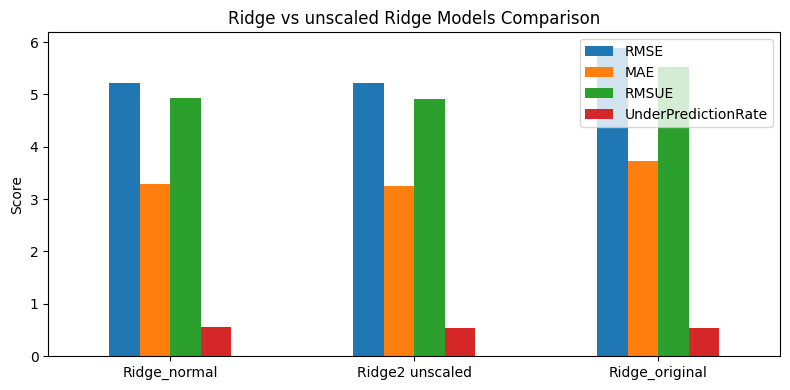

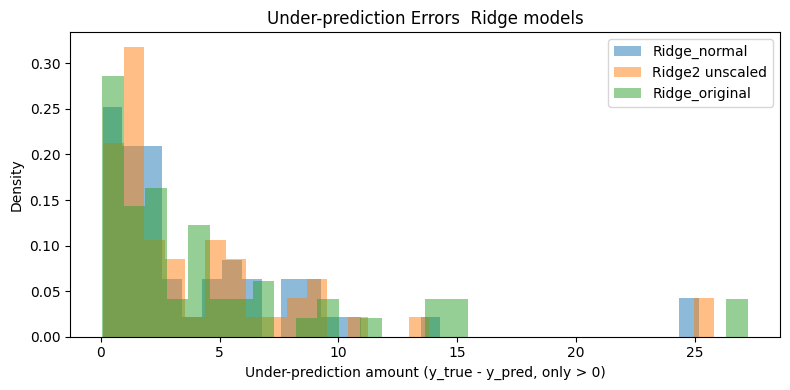

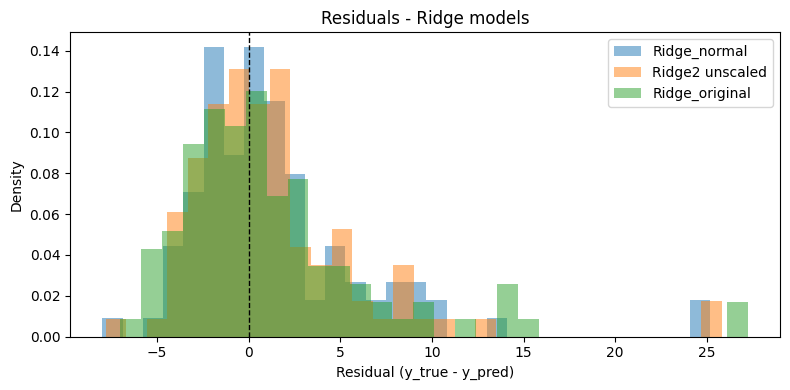

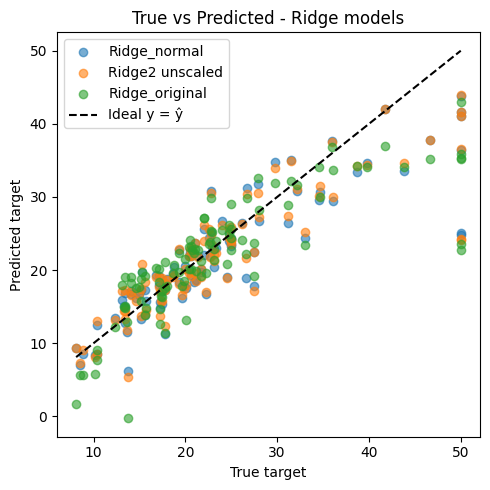

In [57]:
preds = {
    "Ridge_normal": y_pred_ridge,
    "Ridge2 unscaled": y_pred_ridge2,
    "Ridge_original": y_pred_ridgeOriginal
}
metrics_df = evaluate_models(y_test_normal, preds)
metrics_df
plot_metric_bars(
    metrics_df,
    metrics=["RMSE", "MAE", "RMSUE", "UnderPredictionRate"],
    title="Ridge vs unscaled Ridge Models Comparison"
)

plot_underprediction_histograms(
    y_test_normal,
    preds,
    title="Under-prediction Errors  Ridge models"
)
plot_residual_histograms(
    y_test_normal,
    preds,
    title="Residuals - Ridge models"
)
plot_true_vs_pred(
    y_test_normal,
    preds,
    title="True vs Predicted - Ridge models"
)

We find that simple preprocessing (log-transforming skewed features and encoding ordinal RAD & ZN as one-hot) reduces RMSE from 5.89 to ≈5.21 and also shrinks large under-predictions. Results are robust to whether the features are standardized or not (RMSE 5.22 vs 5.21).

# Random Forest Preprocessing

In [58]:


df_bostonhousing_RF = df_bostonhousing.copy()

target_col = "MEDV"

X_rf_raw = df_bostonhousing_RF.drop(columns=[target_col])
y_rf     = df_bostonhousing_RF[target_col]

X_train_rf = X_rf_raw.iloc[train_idx]
X_test_rf  = X_rf_raw.iloc[test_idx]
y_train_rf = y_rf.iloc[train_idx]
y_test_rf  = y_rf.iloc[test_idx] 


FOR RF WE DON'T need standard scalars and as long as it's numeric it's all that matters. And in terms of stratified data we can use the same indexes as we used previously for the other data 

In [59]:
rf = RandomForestRegressor(
    n_estimators=800,
    max_depth=10,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_rf, y_train_rf)

y_pred_rf = rf.predict(X_test_rf)


In [60]:
metrics_rf = regression_metrics(y_test_rf, y_pred_rf)
metrics_rf
# OLD unoptimized results - n_estimators=500, max_depth=None,
# {'RMSE': np.float64(4.822957713740539),
#  'MAE': 2.538644629781008,
#  'R2': 0.7721888907063852,
#  'RMSUE': np.float64(4.459900914214378),
#  'UnderPredictionRate': np.float64(0.49019607843137253)}

{'RMSE': np.float64(4.316402564067837),
 'MAE': 2.4531700873987283,
 'R2': 0.8175298310593111,
 'RMSUE': np.float64(3.9169381679305175),
 'UnderPredictionRate': np.float64(0.5392156862745098)}

In [61]:
feature_importances = pd.Series(
    rf.feature_importances_,
    index=X_train_rf.columns
).sort_values(ascending=False)

feature_importances.head(15)


RM         0.417006
LSTAT      0.407350
CRIM       0.046935
DIS        0.041632
NOX        0.018981
TAX        0.017816
PTRATIO    0.017679
AGE        0.017134
INDUS      0.009240
RAD        0.004781
ZN         0.001447
dtype: float64

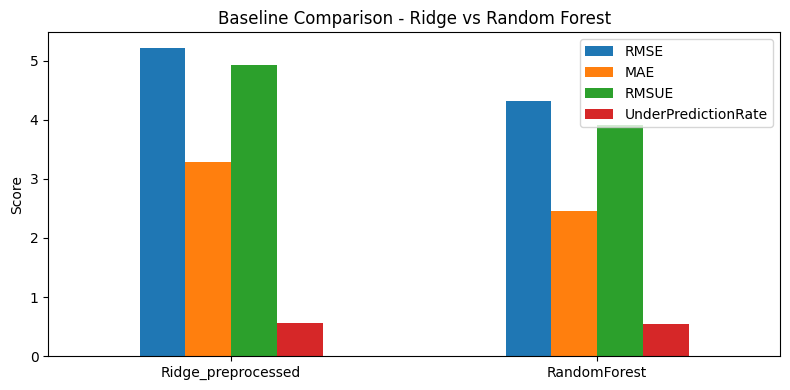

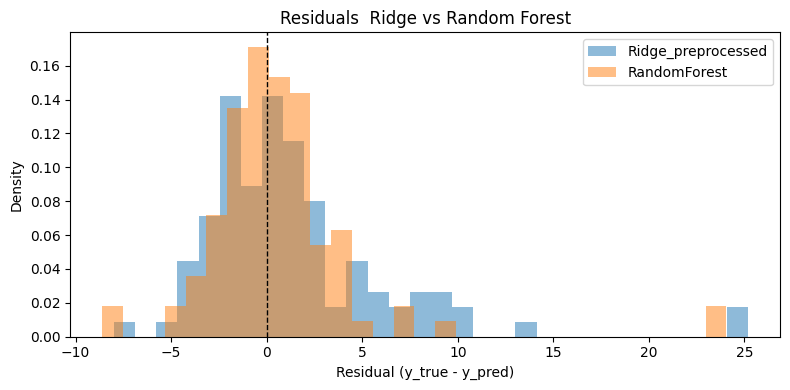

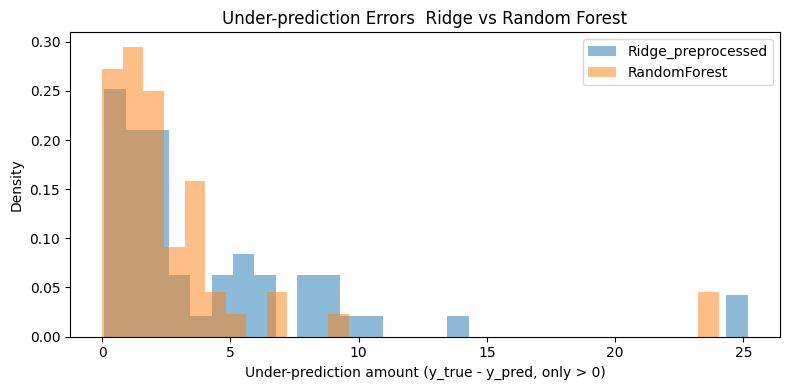

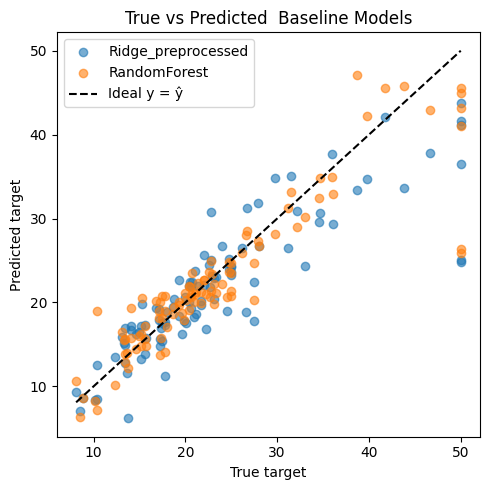

In [62]:
preds_baselines = {
    "Ridge_preprocessed": y_pred_ridge_best,
    "RandomForest": y_pred_rf
}

metrics_df_baselines = evaluate_models(y_test_normal, preds_baselines)
metrics_df_baselines

plot_metric_bars(
    metrics_df_baselines,
    metrics=["RMSE", "MAE", "RMSUE", "UnderPredictionRate"],
    title="Baseline Comparison - Ridge vs Random Forest"
)
plot_residual_histograms(
    y_test_normal,
    preds_baselines,
    title="Residuals  Ridge vs Random Forest"
)
plot_underprediction_histograms(
    y_test_normal,
    preds_baselines,
    title="Under-prediction Errors  Ridge vs Random Forest"
)
plot_true_vs_pred(
    y_test_normal,
    preds_baselines,
    title="True vs Predicted  Baseline Models"
)


# MSUE Linear Regression Model

In [63]:
from rmsue_lin_reg import *

X_train_for_model = np.asarray(X_train_scaled, dtype=float)
X_test_for_model  = np.asarray(X_test_scaled, dtype=float)
y_train_for_model = np.asarray(y_train_normal, dtype=float).reshape(-1,)
y_test_for_model  = np.asarray(y_test_normal, dtype=float).reshape(-1,)

# grid search
alpha_grid   = [0.001, 0.01, 0.05]
epoch_grid   = [500, 1000, 2000]
gamma_grid = [1.2, 1.5, 2.0, 5.0, 10.0]

best_score = float("inf")
best_params = None
best_w = None

for alpha in alpha_grid:
    for n_epoch in epoch_grid:
        for gamma in gamma_grid:

            print(f"Training with alpha={alpha}, epoch={n_epoch}, gamma={gamma}")

            # Train model
            w_msue = train(
                X_train_for_model,
                y_train_for_model,
                alpha=alpha,
                n_epoch=n_epoch,
                gamma=gamma
            )

            # Predict / evaluate
            y_pred = compute_yhat(X_test_for_model, w_msue).reshape(-1,)
            metrics = regression_metrics(y_test_for_model, y_pred)

            print(f"  RMSE:  {metrics['RMSE']}")
            print(f"  MAE:   {metrics['MAE']}")
            print(f"  RMSUE: {metrics['RMSUE']}\n")

            # selection metric is 2 * RMSUE + RMSE to balance both
            score = (2 * metrics['RMSUE']) + metrics['RMSE']
            if score < best_score:
                best_score = score
                best_params = (alpha, n_epoch, gamma)
                best_w = w_msue

print("\nBest parameters found:")
print(f"  alpha   = {best_params[0]}")
print(f"  n_epoch = {best_params[1]}")
print(f"  gamma   = {best_params[2]}")
print(f"  Best RMSUE = {best_score}")

# Evaluate best model
y_pred_best = compute_yhat(X_test_for_model, best_w).reshape(-1,)
best_metrics = regression_metrics(y_test_for_model, y_pred_best)

print("\nMetrics for best model:")
for k, v in best_metrics.items():
    print(f"  {k}: {v}")

Training with alpha=0.001, epoch=500, gamma=1.2
  RMSE:  14.945195519731039
  MAE:   13.327895637853562
  RMSUE: 14.945195519731039

Training with alpha=0.001, epoch=500, gamma=1.5
  RMSE:  13.317876876768162
  MAE:   11.604441792654622
  RMSUE: 13.317876876768162

Training with alpha=0.001, epoch=500, gamma=2.0
  RMSE:  11.170335862442915
  MAE:   9.252666770376626
  RMSUE: 11.170335862442915

Training with alpha=0.001, epoch=500, gamma=5.0
  RMSE:  6.1470912373375475
  MAE:   3.769457528295375
  RMSUE: 6.012879118578999

Training with alpha=0.001, epoch=500, gamma=10.0
  RMSE:  5.223762812915707
  MAE:   3.626432299166324
  RMSUE: 4.192222794662387

Training with alpha=0.001, epoch=1000, gamma=1.2
  RMSE:  9.869766129123429
  MAE:   7.767311869858654
  RMSUE: 9.869704654343883

Training with alpha=0.001, epoch=1000, gamma=1.5
  RMSE:  8.432698969621896
  MAE:   6.105993849211612
  RMSUE: 8.427594024977783

Training with alpha=0.001, epoch=1000, gamma=2.0
  RMSE:  6.972900646909679
  

# MSUE Ridge Regression Model

In [64]:
from rmsue_ridge_reg import *

X_train_for_model = np.asarray(X_train_scaled, dtype=float)
X_test_for_model  = np.asarray(X_test_scaled, dtype=float)
y_train_for_model = np.asarray(y_train_normal, dtype=float).reshape(-1,)
y_test_for_model  = np.asarray(y_test_normal, dtype=float).reshape(-1,)

# grid search
alpha_grid   = [0.001, 0.01, 0.05]
lambda_grid  = [0.01, 0.1, 1.0]
epoch_grid   = [500, 1000, 2000]
gamma_grid   = [1.2, 1.5, 2.0, 5.0, 10.0]

best_score  = float("inf")
best_params = None
best_w      = None

for alpha in alpha_grid:
    for lam in lambda_grid:
        for n_epoch in epoch_grid:
            for gamma in gamma_grid:
                print(f"Training with alpha={alpha}, lambda={lam}, "
                      f"n_epoch={n_epoch}, gamma={gamma} ...")

                w_ridge_msue = train_ridge(
                    X_train_for_model,
                    y_train_for_model,
                    alpha=alpha,
                    lambda_ridge=lam,
                    n_epoch=n_epoch,
                    gamma=gamma
                )

                # Predict / evaluate
                y_pred = compute_yhat_ridge(X_test_for_model, w_ridge_msue).reshape(-1,)
                metrics = regression_metrics(y_test_for_model, y_pred)

                print(f"  RMSE:  {metrics['RMSE']}")
                print(f"  MAE:   {metrics['MAE']}")
                print(f"  RMSUE: {metrics['RMSUE']}\n")

                # selection metric is 2 * RMSUE + RMSE to balance both
                score = (2 * metrics['RMSUE']) + metrics['RMSE']
                if score < best_score:
                    best_score = score
                    best_params = (alpha, n_epoch, lam, gamma)
                    best_w = w_msue


print("\nBest parameters found:")
print(f"  alpha      = {best_params[0]}")
print(f"  lambda_reg = {best_params[1]}")
print(f"  n_epoch    = {best_params[2]}")
print(f"  gamma      = {best_params[3]}")
print(f"  Best RMSUE = {best_score}")

# Evaluate best model
y_pred_best = compute_yhat_ridge(X_test_for_model, best_w).reshape(-1,)
best_metrics = regression_metrics(y_test_for_model, y_pred_best)

print("\nMetrics for best model:")
for k, v in best_metrics.items():
    print(f"  {k}: {v}")


Training with alpha=0.001, lambda=0.01, n_epoch=500, gamma=1.2 ...
  RMSE:  14.946640865216501
  MAE:   13.327920549298852
  RMSUE: 14.946640865216501

Training with alpha=0.001, lambda=0.01, n_epoch=500, gamma=1.5 ...
  RMSE:  13.319518783496829
  MAE:   11.604525370521356
  RMSUE: 13.319518783496829

Training with alpha=0.001, lambda=0.01, n_epoch=500, gamma=2.0 ...
  RMSE:  11.172221679024807
  MAE:   9.25279438000082
  RMSUE: 11.172221679024807

Training with alpha=0.001, lambda=0.01, n_epoch=500, gamma=5.0 ...
  RMSE:  6.149514712900233
  MAE:   3.769927846764767
  RMSUE: 6.015374662793745

Training with alpha=0.001, lambda=0.01, n_epoch=500, gamma=10.0 ...
  RMSE:  5.225855600901708
  MAE:   3.6274336116134474
  RMSUE: 4.194782232227698

Training with alpha=0.001, lambda=0.01, n_epoch=1000, gamma=1.2 ...
  RMSE:  9.87381380891536
  MAE:   7.767506903630092
  RMSUE: 9.873753569422373

Training with alpha=0.001, lambda=0.01, n_epoch=1000, gamma=1.5 ...
  RMSE:  8.437040294999811
  